# Checking out the (possibly) most promising dataset

... though that _possibly_ is yet to be confirmed:
- there are no road annotations
- would need to crop large tiles and curate appropriately
- and found some irregularities in the data..?

Still, it has uniform ground resolution, a lot of images, and bounding boxes which make sampling (and transforms) relatively easy.


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('..')

import src.plotting as splot
import src.data_utils as sduti

## Set up namespace, e.g. point to data

In [3]:
def filter_di( dict_, func_):
    return {k:v for k,v in dict_.items() if func_((k,v))}

def filter_li( list_, func_):
    return [l for l in list_ if func_(l)]

def center_on_bbox( bbox, res, xmax, ymax):
    x1, y1, x2, y2 = bbox
    x, y = x1 + int( (x2 - x1)/2), y1 + int( (y2 - y1)/2)    
    x1_, x2_ = x - int( res/2), int(x + res/2)    
    y1_, y2_ = y - int( res/2), int(y + res/2)    
    try:
        assert x1_ >= 0 and x2_ <= xmax and y1_ >=0 and y2_ <= ymax
        return (x1_, y1_, x2_, y2_),(x1 - x1_, y1 - y1_, x2 - x1_, y2 - y1_)
    except AssertionError:
        return None, None

def crop_to_bbox( image_array, bbox):
    x1, y1, x2, y2 = bbox
    return image_array[:,x1:x2,:][y1:y2,:,:]

In [4]:
data_path = '../../xView-train_images/'
label_file = '../../xView_train.geojson'

In [5]:
labelnames_di = {
    11:'Fixed-wing Aircraft', 12:'Small Aircraft', 13:'Passenger/Cargo Plane', 15:'Helicopter',
    17:'Passenger Vehicle', 18:'Small Car', 19:'Bus', 20:'Pickup Truck', 21:'Utility Truck',
    23:'Truck', 24:'Cargo Truck', 25:'Truck Tractor w/ Box Trailer', 26:'Truck Tractor',27:'Trailer',
    28:'Truck Tractor w/ Flatbed Trailer', 29:'Truck Tractor w/ Liquid Tank', 32:'Crane Truck',
    33:'Railway Vehicle', 34:'Passenger Car', 35:'Cargo/Container Car', 36:'Flat Car', 37:'Tank car',
    38:'Locomotive', 40:'Maritime Vessel', 41:'Motorboat', 42:'Sailboat', 44:'Tugboat', 45:'Barge',
    47:'Fishing Vessel', 49:'Ferry', 50:'Yacht', 51:'Container Ship', 52:'Oil Tanker',
    53:'Engineering Vehicle', 54:'Tower crane', 55:'Container Crane', 56:'Reach Stacker',
    57:'Straddle Carrier', 59:'Mobile Crane', 60:'Dump Truck', 61:'Haul Truck', 62:'Scraper/Tractor',
    63:'Front loader/Bulldozer', 64:'Excavator', 65:'Cement Mixer', 66:'Ground Grader', 71:'Hut/Tent',
    72:'Shed', 73:'Building', 74:'Aircraft Hangar', 76:'Damaged Building', 77:'Facility', 79:'Construction Site',
    83:'Vehicle Lot', 84:'Helipad', 86:'Storage Tank', 89:'Shipping container lot', 91:'Shipping Container',
    93:'Pylon', 94:'Tower'}
labelnames_di_ = {v:k for k,v in labelnames_di.items()}

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [6]:
label_di = sduti.from_json( label_file)
for k,v in label_di.items():
    print(k,type(v))

crs <class 'dict'>
type <class 'str'>
features <class 'list'>
name <class 'str'>


In [9]:
label_di['crs'], label_di['type'], label_di['name'], len(label_di['features'])

({'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}, 'type': 'name'},
 'FeatureCollection',
 'U-LIMDIS_xView_Final',
 601937)

In [8]:
label_li = label_di['features']
label_li[0]

{'type': 'Feature',
 'properties': {'bounds_imcoords': '2712,1145,2746,1177',
  'edited_by': 'wwoscarbecerril',
  'cat_id': '1040010028371A00',
  'type_id': 73,
  'ingest_time': '2017/07/24 12:49:09.118+00',
  'index_right': 2356,
  'image_id': '2355.tif',
  'point_geom': '0101000020E6100000616E4E6406A256C03BE6ADA0D6212D40',
  'feature_id': 374410,
  'grid_file': 'Grid2.shp'},
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-90.53169885094464, 14.56603647302396],
    [-90.53169885094464, 14.56614473506768],
    [-90.53158140073565, 14.56614473506768],
    [-90.53158140073565, 14.56603647302396],
    [-90.53169885094464, 14.56603647302396]]]}}

In [21]:
df = pd.DataFrame([x['properties'] for x in label_li])
df.drop(
    labels= ['edited_by','cat_id','point_geom','grid_file','ingest_time'], axis= 1, inplace= True
)
df['cat'] = df['type_id'].map( labelnames_di)
df['bbox'] = df['bounds_imcoords'].map( lambda x: [int(y) for y in x.split(',')])

In [43]:
df.head(3)

,bounds_imcoords,type_id,index_right,image_id,feature_id,cat,bbox
0,"2712,1145,2746,1177",73,2356,2355.tif,374410,Building,"[2712, 1145, 2746, 1177]"
1,"2720,2233,2760,2288",73,2356,2355.tif,394393,Building,"[2720, 2233, 2760, 2288]"
2,"2687,1338,2740,1399",73,2356,2355.tif,374031,Building,"[2687, 1338, 2740, 1399]"


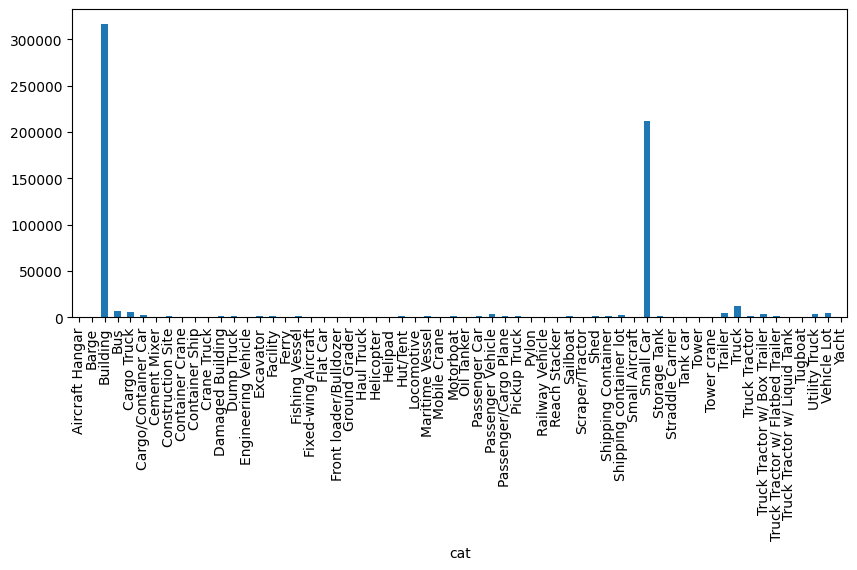

In [27]:
plt.subplots( figsize= (10,4))
_ = df.groupby('cat').count()['type_id'].plot(kind='bar')

In [62]:
dfg = df.groupby('image_id').agg(
    {'type_id': [ len, lambda x: len(set(x))]}
).droplevel(level=0,axis=1).rename( 
    columns= {'<lambda_0>': 'n_cats', 'len': 'n_labels'}
)
for item in dfg.index:
    try:
        image_ = sduti.to_numpy( sduti.load_image( f'{data_path}{item}'))
        dfg.loc[ item, ['dims','mean','var']] = str(image_.shape), image_.mean(), image_.var()
    except FileNotFoundError:
        print( f'{item} is missing...')

1395.tif is missing...


In [61]:
dfg.head(3)

,n_labels,n_cats,dims,mean,var
image_id,,,,,
10.tif,63,7,"(3228, 3320, 3)",71.567849,461.303075
100.tif,135,3,"(2714, 3379, 3)",1.937037,173.922824
102.tif,1965,9,"(2713, 3378, 3)",50.468606,1424.313781


<Axes: >

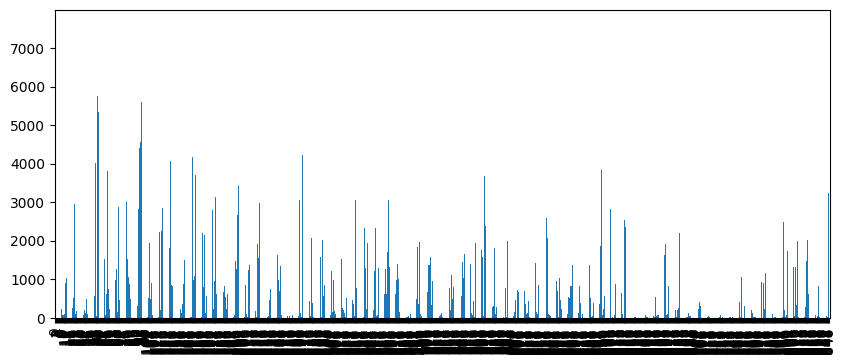

In [53]:
plt.subplots( figsize= (10,4))
dfg.reset_index()['len'].plot(kind='bar')

(array([18., 13., 11., 16., 12., 21., 28., 23., 28., 35., 43., 39., 23.,
        26., 26., 18., 20., 24., 19., 20., 14., 25., 26., 22., 15., 17.,
        18., 17., 16., 15., 14., 13., 11., 12.,  9., 12., 10., 10.,  8.,
         5.,  6.,  5.,  3.,  5.,  5.,  1.,  3.,  2.,  5., 59.]),
 array([   9.96094368,   49.76172481,   89.56250593,  129.36328706,
         169.16406818,  208.96484931,  248.76563044,  288.56641156,
         328.36719269,  368.16797382,  407.96875494,  447.76953607,
         487.5703172 ,  527.37109832,  567.17187945,  606.97266058,
         646.7734417 ,  686.57422283,  726.37500395,  766.17578508,
         805.97656621,  845.77734733,  885.57812846,  925.37890959,
         965.17969071, 1004.98047184, 1044.78125297, 1084.58203409,
        1124.38281522, 1164.18359635, 1203.98437747, 1243.7851586 ,
        1283.58593972, 1323.38672085, 1363.18750198, 1402.9882831 ,
        1442.78906423, 1482.58984536, 1522.39062648, 1562.19140761,
        1601.99218874, 1641.79296986

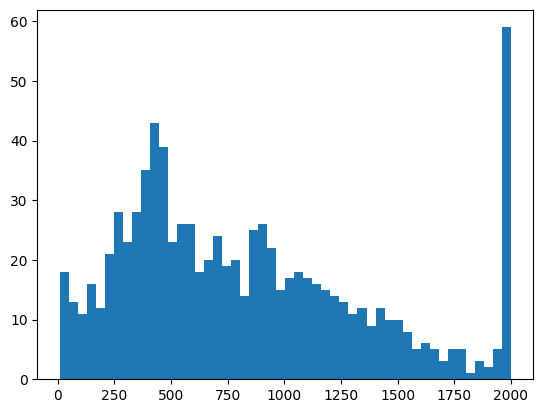

In [69]:
plt.hist(dfg['var'].clip(upper=2000),bins=50)

In [107]:
target_ims = dfg.loc[ dfg['var']<100].index.tolist()
print(f'{len(target_ims)} images')

35 images


In [111]:
sample_im_name = target_ims[0]
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = sduti.to_numpy( sduti.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
df_.shape

(23, 7)

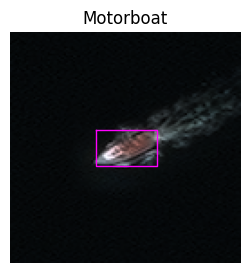

In [112]:
which = 2
bbox = df_.iloc[ which]['bbox']
category = df_.iloc[ which]['cat']
image_bbox, bbox_inner = center_on_bbox( bbox, 128, xmax, ymax)
if image_bbox is not None:
    ax = splot.plot_single( crop_to_bbox( image_, image_bbox), figsize= (3,3))
    splot.plot_bbox( *bbox_inner, ax= ax)
    ax.set_title( category)

In [116]:
target_cond = ( df['cat'] == 'Small Car')
target_ids = df.loc[ target_cond].index
target_ims = df.loc[ target_ids, 'image_id'].unique()
print(f'{len(target_ids)} entries across {len(target_ims)} images')
sample_im_name = df.loc[ target_ids,'image_id'].unique()[0]

211664 entries across 692 images


In [113]:
sample_im_name = target_ims[0]
image_ = sduti.to_numpy( sduti.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape

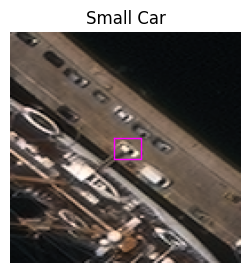

In [117]:
which = 7
bbox = df_.iloc[ which]['bbox']
category = df_.iloc[ which]['cat']
image_bbox, bbox_inner = center_on_bbox( bbox, 128, xmax, ymax)
if image_bbox is not None:
    ax = splot.plot_single( crop_to_bbox( image_, image_bbox), figsize= (3,3))
    splot.plot_bbox( *bbox_inner, ax= ax)
    ax.set_title( category)